# BIDS EEG Data Reader

This notebook demonstrates how to load, inspect, and visualize EEG data from a BIDS (Brain Imaging Data Structure) formatted dataset using MNE-Python and MNE-BIDS libraries.

## 1. Import Required Libraries

Import necessary libraries for reading and visualizing BIDS EEG data.

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MNE and BIDS libraries
import mne
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Set BIDS Dataset Path

Define the path to your BIDS dataset directory. This should be the root directory containing the BIDS structure with subdirectories like `sub-*/ses-*/eeg/`.

In [2]:
# Set the path to your BIDS dataset
# Update this path to point to your BIDS dataset root directory
bids_root = r"../lemanic-g02/ds003969-download"

# Verify that the directory exists
if os.path.isdir(bids_root):
    print(f"BIDS root directory found: {bids_root}")
    print(f"Contents: {os.listdir(bids_root)}")
else:
    print(f"ERROR: BIDS root directory not found at {bids_root}")

BIDS root directory found: ../lemanic-g02/ds003969-download
Contents: ['CHANGES', 'README', '.gitattributes', 'annex-uuid', 'dataset_description.json', 'participants.json', 'participants.tsv', 'code', 'sourcedata', 'sub-003', 'sub-002', 'sub-001', 'sub-006', 'sub-005', 'sub-008', 'sub-007', 'sub-004', 'sub-010', 'sub-011', 'sub-013', 'sub-012', 'sub-009', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-024', 'sub-018', 'sub-026', 'sub-027', 'sub-019', 'sub-029', 'sub-020', 'sub-025', 'sub-030', 'sub-028', 'sub-032', 'sub-021', 'sub-031', 'sub-033', 'sub-034', 'sub-035', 'sub-036', 'sub-022', 'sub-023', 'sub-037', 'sub-038', 'sub-040', 'sub-039', 'sub-041', 'sub-042', 'sub-044', 'sub-043', 'sub-047', 'sub-048', 'sub-045', 'sub-049', 'sub-051', 'sub-050', 'sub-046', 'sub-052', 'sub-053', 'sub-055', 'sub-054', 'sub-056', 'sub-057', 'sub-058', 'sub-061', 'sub-059', 'sub-060', 'sub-063', 'sub-064', 'sub-062', 'sub-065', 'sub-067', 'sub-066', 'sub-068', 'sub-070', 'sub-069', 'sub-071', 'sub

## 3. Load BIDS Dataset Structure

Explore the BIDS dataset structure and list available subjects and sessions.

In [3]:
# Get list of subjects in the BIDS dataset
try:
    subjects = get_entity_vals(bids_root, entity_key='subject')
    print(f"Available subjects: {subjects}")
    print(f"Number of subjects: {len(subjects)}\n")
    
    # Get sessions if available
    sessions = get_entity_vals(bids_root, entity_key='session')
    if sessions:
        print(f"Available sessions: {sessions}")
        print(f"Number of sessions: {len(sessions)}\n")
    
    # Get tasks
    tasks = get_entity_vals(bids_root, entity_key='task')
    if tasks:
        print(f"Available tasks: {tasks}")
        print(f"Number of tasks: {len(tasks)}\n")
    
except Exception as e:
    print(f"Error exploring BIDS structure: {e}")

Available subjects: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098']
Number of subjects: 98

Available tasks: ['med1breath', 'med2', 'think1', 'think2']
Number of tasks: 4



## 4. Read EEG Data Files

Load EEG data files using `read_raw_bids()` function. This example reads the first subject's EEG data.

In [4]:
# Read EEG data for the first subject
try:
    if subjects:
        # Create a BIDS path for the first subject
        subject = subjects[0]
        session = sessions[0] if sessions else None
        task = tasks[0] if tasks else None
        
        bids_path = BIDSPath(
            subject=subject,
            session=session,
            task=task,
            datatype='eeg',
            root=bids_root
        )
        
        print(f"Reading BIDS file: {bids_path}")
        
        # Read the raw EEG data
        raw = read_raw_bids(bids_path=bids_path, verbose=True)
        print(f"✓ Successfully loaded EEG data!")
        print(f"Data shape: {raw.get_data().shape}")
        
    else:
        print("No subjects found in the BIDS dataset!")
        raw = None
        
except Exception as e:
    print(f"Error reading EEG data: {e}")
    raw = None

Reading BIDS file: ../lemanic-g02/ds003969-download/sub-001/eeg/sub-001_task-med1breath_eeg.bdf
Extracting BDF parameters from ../lemanic-g02/ds003969-download/sub-001/eeg/sub-001_task-med1breath_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading channel info from ../lemanic-g02/ds003969-download/sub-001/eeg/sub-001_task-med1breath_channels.tsv.


/tmp/ipykernel_4712/1882035225.py:20: RuntimeWarning: Did not find any events.tsv associated with sub-001_task-med1breath.

The search_str was "../lemanic-g02/ds003969-download/sub-001/**/eeg/sub-001*events.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=True)
/tmp/ipykernel_4712/1882035225.py:20: RuntimeWarning: The number of channels in the channels.tsv sidecar file (79) does not match the number of channels in the raw data file (80). Will not try to set channel names.
  raw = read_raw_bids(bids_path=bids_path, verbose=True)
/tmp/ipykernel_4712/1882035225.py:20: RuntimeWarning: Unable to map the following column(s) to to MNE:
gender: m
group: htr
ethnicity: indian
first_session: meditation
sleep: 6
education: 0
years_of_practice: 3
notes: n/a
  raw = read_raw_bids(bids_path=bids_path, verbose=True)


✓ Successfully loaded EEG data!
Data shape: (80, 620544)


## 5. Inspect EEG Data

Examine the EEG data properties including sampling rate, number of channels, duration, and channel information.

In [5]:
# Inspect the loaded data
if raw is not None:
    print("=" * 60)
    print("EEG DATA PROPERTIES")
    print("=" * 60)
    print(f"Sampling frequency: {raw.info['sfreq']} Hz")
    print(f"Number of channels: {len(raw.info['ch_names'])}")
    print(f"Channel names: {raw.info['ch_names']}")
    print(f"Data type: {raw.info['chs'][0]['kind']}")
    print(f"Recording duration: {raw.times[-1]:.2f} seconds ({raw.times[-1]/60:.2f} minutes)")
    print(f"Total number of samples: {raw.get_data().shape[1]}")
    print(f"Data shape (channels × samples): {raw.get_data().shape}")
    
    # Print summary information
    print("\n" + "=" * 60)
    print("CHANNEL INFORMATION")
    print("=" * 60)
    ch_types_dict = {}
    for ch_type in raw.get_channel_types():
        if ch_type not in ch_types_dict:
            ch_types_dict[ch_type] = 0
        ch_types_dict[ch_type] += 1
    
    for ch_type, count in ch_types_dict.items():
        print(f"{ch_type.upper()}: {count} channel(s)")
else:
    print("No raw data loaded. Please check the BIDS path and dataset structure.")

EEG DATA PROPERTIES
Sampling frequency: 1024.0 Hz
Number of channels: 80
Channel names: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']
Data type: 2 (FIFFV_EEG_CH)
Recording duration: 606.00 seconds (10.10 minutes)
Total number of samples: 620544
Data shape (channels × samples): (80, 620544)

CHANNEL INFORMATION
EEG: 64 channel(s)
MISC: 11 channel(s)
GSR: 2 channel(s)
RESP: 1 channel(s)
TEMPERATURE: 1 channel(s)
STIM: 1 channel(s)


## 6. Visualize EEG Signals

Plot and visualize the EEG signals to inspect data quality and signal characteristics.

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']
Using matplotlib as 2D backend.


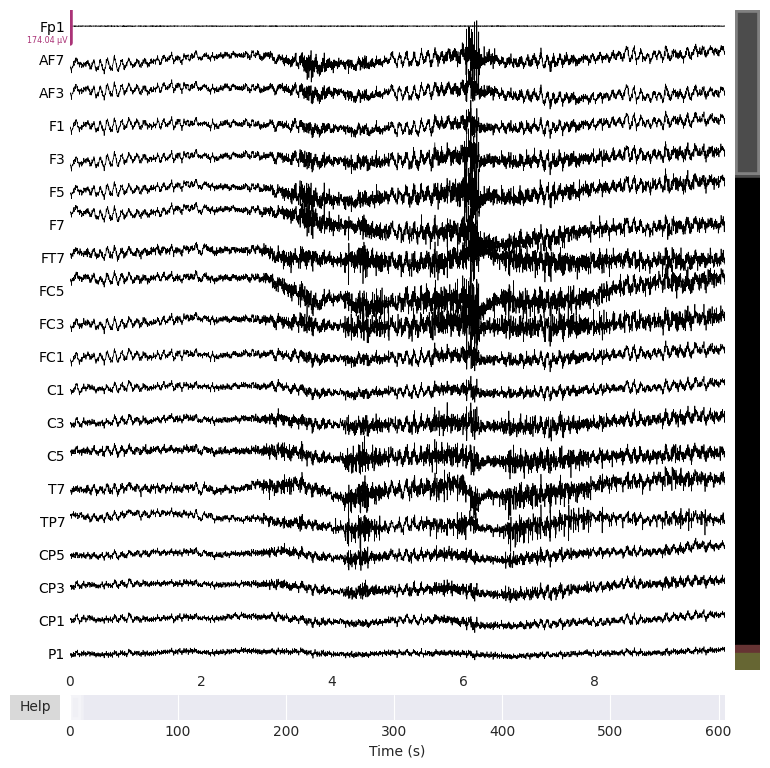

<Figure size 640x480 with 0 Axes>

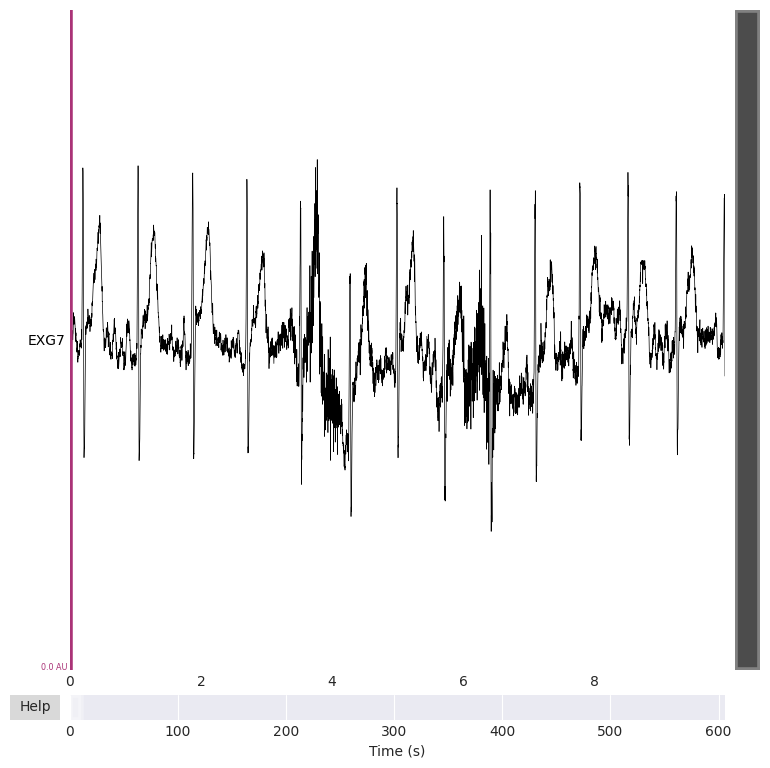

Effective window size : 2.000 (s)


TypeError: BaseSpectrum.plot() got an unexpected keyword argument 'ax'

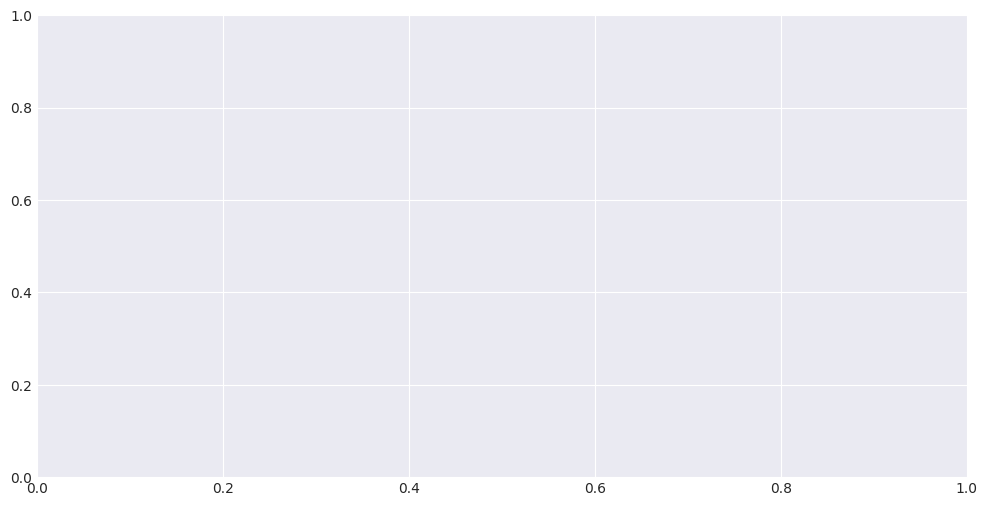

In [6]:
# Visualize the first 10 seconds of EEG data
if raw is not None:
    print(raw.ch_names)

    # Plot a portion of the data
    fig = raw.plot(duration=10, n_channels=20, scalings='auto')
    plt.suptitle('EEG Signals - First 10 Seconds', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    raw.copy().pick(['EXG7']).plot()
    plt.show()

    # Create a power spectral density plot
    fig, ax = plt.subplots(figsize=(12, 6))
    raw.compute_psd(fmin=0.5, fmax=50, n_jobs=1).plot(ax= ax, show=False)
    ax.set_title('Power Spectral Density (PSD) - EEG Signals', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Plot channel locations (if montage is available)
    try:
        fig = raw.plot_sensors()
        plt.suptitle('EEG Channel Locations', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot channel locations: {e}")
else:
    print("No raw data to visualize. Please load data from a BIDS file first.")

In [ ]:
from mne.datasets import sample
import mne

data_path = sample.data_path()

raw = mne.io.read_raw_fif(
    data_path / "MEG" / "sample" / "sample_audvis_raw.fif",
    preload=True
)

In [20]:
"""
EEG Meditation Feature Extraction & Score Pipeline
====================================================
Fixes applied vs original:
  - hjorth_parameters now returns (activity, mobility, complexity) arrays,
    separate from the DataFrame builder (hjorth_to_df)
  - hjorth_per_band uses epochs.get_data() and calls the corrected helper
  - compute_entropy_features: removed dangling statement, fixed 'General Entropy' key
  - compute_connectivity_features: freq_bands variable name unified
  - feature_extraction: passes epochs.get_data() to hjorth, assembles final DataFrame
  - bandpower dict converted to DataFrame
  - MeditationScorer class maps features -> user-friendly scores
"""
 
import numpy as np
import pandas as pd
from scipy import stats
import mne
from mne_connectivity import spectral_connectivity_epochs
 
 
# ---------------------------------------------------------------------------
# Frequency bands
# ---------------------------------------------------------------------------
 
FREQ_BANDS = {
    "delta": (1,  4),
    "theta": (4,  8),
    "alpha": (8,  12),
    "beta":  (12, 30),
    "gamma": (30, 45),
}
 
 
# ---------------------------------------------------------------------------
# Hjorth parameters
# ---------------------------------------------------------------------------
 
def hjorth_parameters(data):
    """
    Compute raw Hjorth arrays for EEG epochs.
 
    Parameters
    ----------
    data : np.ndarray, shape (n_epochs, n_channels, n_times)
 
    Returns
    -------
    activity   : (n_epochs, n_channels)
    mobility   : (n_epochs, n_channels)
    complexity : (n_epochs, n_channels)
    """
    d1 = np.diff(data, n=1, axis=-1)
    d2 = np.diff(data, n=2, axis=-1)
 
    var_x  = data.var(axis=-1)
    var_d1 = d1.var(axis=-1)
    var_d2 = d2.var(axis=-1)
 
    activity   = var_x
    mobility   = np.sqrt(var_d1 / (var_x + 1e-12))
    complexity = np.sqrt(var_d2 / (var_d1 + 1e-12)) / (mobility + 1e-12)
 
    return activity, mobility, complexity
 
 
def hjorth_to_df(data, ch_names):
    """Build a tidy DataFrame from Hjorth arrays (drops activity — redundant with band power)."""
    activity, mobility, complexity = hjorth_parameters(data)
 
    mob_cols  = [f"hjorth_mobility_{ch}"   for ch in ch_names]
    comp_cols = [f"hjorth_complexity_{ch}" for ch in ch_names]
 
    return pd.DataFrame(
        np.concatenate([mobility, complexity], axis=1),
        columns=mob_cols + comp_cols,
    )
 
 
def hjorth_per_band(epochs, freq_bands=FREQ_BANDS):
    """Hjorth mobility & complexity computed inside each frequency band."""
    ch_names = epochs.ch_names
    rows = []
 
    for band, (fmin, fmax) in freq_bands.items():
        ep   = epochs.copy().filter(fmin, fmax, method="iir", verbose=False)
        data = ep.get_data()                          # (n_epochs, n_ch, n_times)
        _, mob, comp = hjorth_parameters(data)
 
        cols  = (
            [f"hjorth_mobility_{band}_{ch}"   for ch in ch_names] +
            [f"hjorth_complexity_{band}_{ch}" for ch in ch_names]
        )
        block = np.concatenate([mob, comp], axis=1)
        rows.append(pd.DataFrame(block, columns=cols))
 
    return pd.concat(rows, axis=1)
 
 
# ---------------------------------------------------------------------------
# Connectivity
# ---------------------------------------------------------------------------
 
def compute_connectivity_features(epochs, freq_bands=FREQ_BANDS):
    """
    Pairwise coherence (upper triangle) for each band.
 
    Returns DataFrame with columns  coh_{band}_ch1-ch2.
    """
    ch_names = epochs.ch_names
    n_ch     = len(ch_names)
    triu_idx = np.triu_indices(n_ch, k=1)
 
    pair_labels = [
        f"{ch_names[i]}-{ch_names[j]}"
        for i, j in zip(*triu_idx)
    ]
 
    rows = []
    for band, (fmin, fmax) in freq_bands.items():
        con = spectral_connectivity_epochs(
            epochs,
            method="coh",
            mode="fourier",
            sfreq=epochs.info["sfreq"],
            fmin=fmin,
            fmax=fmax,
            faverage=True,
            verbose=False,
        )
        # con.get_data() -> (n_connections, n_freqs_or_1)
        # With faverage=True the last dim is 1; squeeze it
        con_matrix = con.get_data(output="dense")  # (n_ch, n_ch, 1)
        con_matrix = con_matrix[:, :, 0]           # (n_ch, n_ch)
 
        # con.get_data(output="dense") averages over epochs already,
        # but we want per-epoch values — use the flat form instead:
        con_flat = con.get_data()                  # (n_connections,)
 
        cols = [f"coh_{band}_{lbl}" for lbl in pair_labels]
        # broadcast to n_epochs rows (connectivity is averaged over epochs in
        # spectral_connectivity_epochs; repeat for shape consistency)
        n_epochs = len(epochs)
        rows.append(
            pd.DataFrame(
                np.tile(con_flat, (n_epochs, 1)),
                columns=cols,
            )
        )
 
    return pd.concat(rows, axis=1)

def compute_connectivity_features(epochs, freq_bands):
    con_features = []

    for band, (fmin, fmax) in freq_bands.items():
        con = spectral_connectivity_epochs(
            epochs,
            method="coh",          # coherence
            mode="fourier",
            sfreq=epochs.info["sfreq"],
            fmin=fmin,
            fmax=fmax,
            faverage=True,         # average within band
            verbose=False
        )
    
        # get connectivity matrix
        con_data = con.get_data()  # shape: (n_epochs, n_nodes, n_nodes)
    
        con_features.append(con_data)
    # stack bands
    con_features = np.stack(con_features, axis=1)

    # Flatten 
    n_epochs, n_bands, n_ch, _ = con_features.shape
    
    triu_idx = np.triu_indices(n_ch, k=1)
    
    features = []
    
    for i in range(n_epochs):
        feat = []
        for b in range(n_bands):
            mat = con_features[i, b]
            feat.extend(mat[triu_idx])  # upper triangle
        features.append(feat)
    
    X_conn = np.array(features)
    df_conn = pd.DataFrame(X_conn)
    return df_conn
 
 
# ---------------------------------------------------------------------------
# Entropy
# ---------------------------------------------------------------------------
 
def compute_entropy_features(psd_data, freqs, freq_bands=FREQ_BANDS):
    """
    Parameters
    ----------
    psd_data : (n_epochs, n_channels, n_freqs)
    freqs    : (n_freqs,)
 
    Returns
    -------
    DataFrame with one spectral-entropy column per band + overall entropy.
    """
    eps = 1e-12
 
    # ── Overall spectral entropy ────────────────────────────────────────────
    psd_norm         = psd_data / (psd_data.sum(axis=-1, keepdims=True) + eps)
    overall_entropy  = -(psd_norm * np.log(psd_norm + eps)).sum(axis=-1)
    # Shape (n_epochs, n_channels) -> one scalar per epoch (mean over channels)
    entropy_dict = {"spectral_entropy_overall": overall_entropy.mean(axis=-1)}
 
    # ── Per-band spectral entropy ───────────────────────────────────────────
    for band, (fmin, fmax) in freq_bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        if not idx.any():
            continue
        band_psd      = psd_data[:, :, idx]
        band_psd_norm = band_psd / (band_psd.sum(axis=-1, keepdims=True) + eps)
        entropy       = -(band_psd_norm * np.log(band_psd_norm + eps)).sum(axis=-1)
        entropy_dict[f"spectral_entropy_{band}"] = entropy.mean(axis=-1)
 
    return pd.DataFrame(entropy_dict)
 
 
# ---------------------------------------------------------------------------
# Band power
# ---------------------------------------------------------------------------
 
def bandpower_from_psd(psd_data, freqs, band):
    fmin, fmax = band
    idx = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(idx):
        return np.zeros((psd_data.shape[0], psd_data.shape[1]))
        
    return psd_data[..., idx].mean(axis=-1)   # (n_epochs, n_channels)
 
 
def bandpower_to_df(psd_data, freqs, ch_names, freq_bands=FREQ_BANDS):
    rows = {}
    for band, frange in freq_bands.items():
        bp = bandpower_from_psd(psd_data, freqs, frange)  # (n_epochs, n_ch)
        print(psd_data.shape, bp.shape, len(ch_names))
        for ci, ch in enumerate(ch_names):
            rows[f"bp_{band}_{ch}"] = bp[:, ci]
    return pd.DataFrame(rows)
 
 
# ---------------------------------------------------------------------------
# Time-domain features
# ---------------------------------------------------------------------------
 
def time_features(data, ch_names):
    """
    Parameters
    ----------
    data : (n_epochs, n_channels, n_times)
    """
    def zcr(x):
        signs     = np.sign(x)
        crossings = np.diff(signs, axis=-1)
        return (crossings != 0).sum(axis=-1) / x.shape[-1]
 
    stat_features = {
        "mean": data.mean(axis=-1),
        "var":  data.var(axis=-1),
        "std":  data.std(axis=-1),
        "ptp":  np.ptp(data, axis=-1),
        "skew": stats.skew(data, axis=-1),
        "kurt": stats.kurtosis(data, axis=-1),
        "rms":  np.sqrt((data ** 2).mean(axis=-1)),
        "zcr":  zcr(data),
    }
 
    blocks = np.concatenate(list(stat_features.values()), axis=1)
    cols   = [
        f"{stat}_{ch}"
        for stat in stat_features
        for ch in ch_names
    ]
    return pd.DataFrame(blocks, columns=cols)


def feature_extraction(raw_clean, freq_bands=FREQ_BANDS, epoch_duration=2.0):
    """
    Run the full feature pipeline on a preprocessed Raw object.
 
    Returns
    -------
    df_features : DataFrame, one row per epoch
    epochs      : mne.Epochs  (kept for downstream use)
    psd_data    : (n_epochs, n_ch, n_freqs)
    freqs       : (n_freqs,)
    """
    # ── Epoch ───────────────────────────────────────────────────────────────
    events = mne.make_fixed_length_events(raw_clean, duration=epoch_duration)
    epochs = mne.Epochs(
        raw_clean, events,
        tmin=0, tmax=epoch_duration,
        baseline=None, preload=True,
    )
    ch_names = epochs.ch_names
    data     = epochs.get_data()                          # (n_epochs, n_ch, n_times)
 
    # ── PSD ─────────────────────────────────────────────────────────────────
    psd_obj           = epochs.compute_psd(
        method="welch", fmin=1, fmax=45, n_fft=256, n_overlap=128,
    )
    psd_data, freqs   = psd_obj.get_data(return_freqs=True)   # (n_epochs, n_ch, n_freqs)
    ch_names_psd = psd_obj.ch_names
    print(len(psd_obj.ch_names))
    # ── Feature blocks ──────────────────────────────────────────────────────
    df_bp       = bandpower_to_df(psd_data, freqs, ch_names_psd, freq_bands)
    df_time     = time_features(data, ch_names)
    df_hjorth   = hjorth_to_df(data, ch_names)
    df_hjorth_b = hjorth_per_band(epochs, freq_bands)
    #df_conn     = compute_connectivity_features(epochs, freq_bands)
    df_entropy  = compute_entropy_features(psd_data, freqs, freq_bands)
 
    df_features = pd.concat(
        [df_bp, df_time, df_hjorth, df_hjorth_b,  df_entropy],
        axis=1,
    )
    #df_conn,
 
    return df_features, epochs, psd_data, freqs



In [21]:
class MeditationScorer:
    """
    Maps extracted EEG features to interpretable 0-100 meditation scores.
 
    Scores
    ------
    focus_score       : Sustained focused attention (beta-driven, low theta)
    calm_score        : Relaxed, non-aroused state (alpha dominant)
    mindfulness_score : Internally directed, aware state (frontal theta + alpha)
    stability_score   : How consistent/stable the mental state is (low entropy)
    drowsiness_risk   : Risk of drifting to sleep (delta/theta dominance)
 
    All scores are percentile-ranked within the session so that the first
    epoch is not unfairly penalised by an arbitrary absolute scale.
    The scorer can also be fitted on a baseline (eyes-closed rest) to
    produce calibrated scores relative to that individual's baseline.
    """
 
    FRONTAL_CHANNELS = {"F3", "F4", "Fz", "AF3", "AF4", "F7", "F8"}
    CENTRAL_CHANNELS = {"C3", "C4", "Cz"}
    OCCIPITAL_CHANNELS = {"O1", "O2", "Oz"}
 
    def __init__(self, ch_names, freq_bands=FREQ_BANDS):
        self.ch_names   = ch_names
        self.freq_bands = freq_bands
        self._baseline  = None   # set via fit_baseline()
 
    # ── helpers ─────────────────────────────────────────────────────────────
 
    def _ch_idx(self, group: set) -> list[int]:
        """Indices of channels belonging to a spatial group."""
        return [i for i, ch in enumerate(self.ch_names) if ch in group]
 
    def _band_mean(self, psd_data, freqs, band_name, ch_idx=None):
        """Mean power in a band, optionally restricted to channel subset."""
        fmin, fmax = self.freq_bands[band_name]
        idx        = (freqs >= fmin) & (freqs <= fmax)
        data       = psd_data[:, ch_idx, :] if ch_idx else psd_data
        return data[:, :, idx].mean(axis=(1, 2))   # (n_epochs,)
 
    @staticmethod
    def _minmax(x):
        rng = x.max() - x.min()
        return (x - x.min()) / (rng + 1e-12)
 
    @staticmethod
    def _percentile_scale(x):
        """Rank-based 0-1 scaling — robust to outliers."""
        from scipy.stats import rankdata
        return (rankdata(x) - 1) / (len(x) - 1 + 1e-12)
 
    # ── baseline calibration ────────────────────────────────────────────────
 
    def fit_baseline(self, psd_baseline, freqs):
        """
        Fit scorer to a resting-state (eyes-closed) PSD.
 
        Parameters
        ----------
        psd_baseline : (n_epochs, n_channels, n_freqs) from a rest recording
        freqs        : matching frequency axis
        """
        self._baseline = {
            band: self._band_mean(psd_baseline, freqs, band)
            for band in self.freq_bands
        }
 
    # ── individual score components ─────────────────────────────────────────
 
    def focus_score(self, psd_data, freqs):
        """
        β / (α + θ)  at frontal channels.
 
        High beta relative to alpha+theta = engaged, directed attention.
        Rises during focused attention meditation (Samatha, breath focus).
        """
        f_idx = self._ch_idx(self.FRONTAL_CHANNELS) or list(range(len(self.ch_names)))
 
        beta  = self._band_mean(psd_data, freqs, "beta",  f_idx)
        alpha = self._band_mean(psd_data, freqs, "alpha", f_idx)
        theta = self._band_mean(psd_data, freqs, "theta", f_idx)
 
        raw = beta / (alpha + theta + 1e-12)
        return self._percentile_scale(raw) * 100
 
    def calm_score(self, psd_data, freqs):
        """
        Posterior/central alpha power, penalised by beta (arousal).
 
        High alpha + low beta = eyes-closed, cortically idle, calm.
        Classic 'relaxation' metric — highest during open-monitoring states.
        """
        oc_idx = (
            self._ch_idx(self.OCCIPITAL_CHANNELS | self.CENTRAL_CHANNELS)
            or list(range(len(self.ch_names)))
        )
 
        alpha = self._band_mean(psd_data, freqs, "alpha", oc_idx)
        beta  = self._band_mean(psd_data, freqs, "beta",  oc_idx)
 
        raw = alpha / (beta + 1e-12)
        return self._percentile_scale(raw) * 100
 
    def mindfulness_score(self, psd_data, freqs):
        """
        Frontal midline theta + moderate alpha (θ/α ratio).
 
        Elevated frontal theta reflects internal monitoring, meta-awareness.
        Particularly associated with open-monitoring (Vipassana-style) practice.
        """
        f_idx = self._ch_idx(self.FRONTAL_CHANNELS | self.CENTRAL_CHANNELS) or list(range(len(self.ch_names)))
 
        theta = self._band_mean(psd_data, freqs, "theta", f_idx)
        alpha = self._band_mean(psd_data, freqs, "alpha", f_idx)
 
        # θ/α > 1 = theta-dominant = mindfulness signature
        raw = theta / (alpha + 1e-12)
        return self._percentile_scale(raw) * 100
 
    def stability_score(self, df_features):
        """
        Inverse spectral entropy, smoothed over a rolling window.
 
        Low entropy = ordered, regular brain rhythm = sustained state.
        Drops when the user's mind wanders or transitions between states.
        """
        if "spectral_entropy_overall" not in df_features.columns:
            raise ValueError("Run compute_entropy_features first.")
 
        entropy = df_features["spectral_entropy_overall"].values
        # Invert: high entropy -> low stability
        raw = -entropy
        return self._percentile_scale(raw) * 100
 
    def drowsiness_risk(self, psd_data, freqs):
        """
        (δ + θ) / (α + β)  — high slow-wave dominance signals sleep onset.
 
        Use as an alert trigger:  > 65 for 3+ consecutive epochs -> warning.
        Importantly different from focus loss: focus loss = beta drop,
        drowsiness = delta/theta surge.
        """
        delta = self._band_mean(psd_data, freqs, "delta")
        theta = self._band_mean(psd_data, freqs, "theta")
        alpha = self._band_mean(psd_data, freqs, "alpha")
        beta  = self._band_mean(psd_data, freqs, "beta")
 
        raw = (delta + theta) / (alpha + beta + 1e-12)
        return self._percentile_scale(raw) * 100
 
    def frontal_alpha_asymmetry(self, psd_data, freqs):
        """
        FAA = ln(F4 alpha) - ln(F3 alpha).
 
        Positive = left-prefrontal dominant = approach motivation, positive affect.
        Negative = right-prefrontal dominant = withdrawal, stress.
        Reported per epoch (not rescaled — the sign carries meaning).
        """
        try:
            f3_idx = self.ch_names.index("F3")
            f4_idx = self.ch_names.index("F4")
        except ValueError:
            return np.full(psd_data.shape[0], np.nan)
 
        fmin, fmax = self.freq_bands["alpha"]
        fidx       = (freqs >= fmin) & (freqs <= fmax)
 
        f3_alpha = psd_data[:, f3_idx, :][:, fidx].mean(axis=-1)
        f4_alpha = psd_data[:, f4_idx, :][:, fidx].mean(axis=-1)
 
        return np.log(f4_alpha + 1e-12) - np.log(f3_alpha + 1e-12)
 
    # ── focus-loss detector ─────────────────────────────────────────────────
 
    def detect_focus_loss(
        self,
        psd_data,
        freqs,
        threshold: float = 35.0,
        min_consecutive: int = 3,
    ) -> np.ndarray:
        """
        Returns a boolean array (n_epochs,) flagging focus-loss events.
 
        A focus-loss event is declared when focus_score < threshold for
        at least `min_consecutive` epochs in a row.  The debounce prevents
        single-epoch artefacts from triggering false alerts.
 
        Parameters
        ----------
        threshold       : focus score below which an epoch is 'at risk'
        min_consecutive : minimum run length before alert fires
 
        Returns
        -------
        alert_mask : (n_epochs,) bool — True = alert should fire this epoch
        """
        scores     = self.focus_score(psd_data, freqs)
        below      = scores < threshold
        alert_mask = np.zeros(len(scores), dtype=bool)
 
        run = 0
        for i, b in enumerate(below):
            run = run + 1 if b else 0
            if run >= min_consecutive:
                alert_mask[i] = True
 
        return alert_mask
 
    # ── full score summary ──────────────────────────────────────────────────
 
    def compute_all(self, psd_data, freqs, df_features):
        """
        Compute all scores and return a tidy DataFrame aligned with epochs.
 
        Returns
        -------
        df_scores : DataFrame with one row per epoch
        summary   : dict with session-level statistics
        """
        df_scores = pd.DataFrame({
            "focus_score":       self.focus_score(psd_data, freqs),
            "calm_score":        self.calm_score(psd_data, freqs),
            "mindfulness_score": self.mindfulness_score(psd_data, freqs),
            "stability_score":   self.stability_score(df_features),
            "drowsiness_risk":   self.drowsiness_risk(psd_data, freqs),
            "faa":               self.frontal_alpha_asymmetry(psd_data, freqs),
            "focus_loss_alert":  self.detect_focus_loss(psd_data, freqs),
        })
 
        summary = {
            "mean_focus":          df_scores["focus_score"].mean(),
            "mean_calm":           df_scores["calm_score"].mean(),
            "mean_mindfulness":    df_scores["mindfulness_score"].mean(),
            "mean_stability":      df_scores["stability_score"].mean(),
            "peak_focus":          df_scores["focus_score"].max(),
            "time_focused_pct":    (df_scores["focus_score"] > 60).mean() * 100,
            "time_drowsy_pct":     (df_scores["drowsiness_risk"] > 65).mean() * 100,
            "n_focus_loss_events": df_scores["focus_loss_alert"].sum(),
            "session_style":       self._classify_session(df_scores),
        }
 
        return df_scores, summary
 
    def _classify_session(self, df_scores):
        """
        Heuristic classification of meditation style from score profile.
 
        focused_attention : high focus, moderate calm
        open_monitoring   : high mindfulness + calm, lower focus
        drowsy            : high drowsiness, low focus
        restless          : low stability throughout
        """
        f = df_scores["focus_score"].mean()
        c = df_scores["calm_score"].mean()
        m = df_scores["mindfulness_score"].mean()
        d = df_scores["drowsiness_risk"].mean()
        s = df_scores["stability_score"].mean()
 
        if d > 65:
            return "drowsy"
        if s < 30:
            return "restless"
        if f > 60 and f > m:
            return "focused_attention"
        if m > 55 and c > 50:
            return "open_monitoring"
        return "mixed"
        
def run_pipeline(raw_clean):
    """
    One-shot function: raw MNE object -> scores DataFrame + summary dict.
    
    Usage
    -----
        df_features, epochs, psd_data, freqs = feature_extraction(raw_clean)
        scorer    = MeditationScorer(epochs.ch_names)
        df_scores, summary = scorer.compute_all(psd_data, freqs, df_features)
    """
    df_features, epochs, psd_data, freqs = feature_extraction(raw_clean)
    scorer = MeditationScorer(epochs.ch_names)
    df_scores, summary = scorer.compute_all(psd_data, freqs, df_features)
    return df_features, df_scores, summary
 
 

In [22]:
df_features, df_scores, summary = run_pipeline(raw)

Not setting metadata
303 matching events found
No baseline correction applied
0 projection items activated
Loading data for 303 events and 2049 original time points ...
1 bad epochs dropped
Effective window size : 0.250 (s)
64
(302, 64, 11) (302, 64) 64
(302, 64, 11) (302, 64) 64
(302, 64, 11) (302, 64) 64
(302, 64, 11) (302, 64) 64
(302, 64, 11) (302, 64) 64


/tmp/ipykernel_4712/3565520446.py:274: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew": stats.skew(data, axis=-1),
/tmp/ipykernel_4712/3565520446.py:275: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "kurt": stats.kurtosis(data, axis=-1),


In [26]:
df_features

,bp_delta_Fp1,bp_delta_AF7,bp_delta_AF3,bp_delta_F1,bp_delta_F3,bp_delta_F5,bp_delta_F7,bp_delta_FT7,bp_delta_FC5,bp_delta_FC3,...,hjorth_complexity_gamma_Resp,hjorth_complexity_gamma_Plet,hjorth_complexity_gamma_Temp,hjorth_complexity_gamma_Status,spectral_entropy_overall,spectral_entropy_delta,spectral_entropy_theta,spectral_entropy_alpha,spectral_entropy_beta,spectral_entropy_gamma
0,1.187537e-15,6.117019e-12,4.880802e-12,5.823825e-12,4.456796e-12,4.261835e-12,6.646121e-12,4.563515e-12,4.056745e-12,4.637538e-12,...,76.068438,1.400320,0.0,31.544643,1.321406,0.212408,0.543347,0.663601,0.794031,0.679098
1,1.171796e-15,5.918287e-12,5.976002e-12,6.074770e-12,5.204211e-12,5.189014e-12,5.327710e-12,5.327686e-12,1.012923e-11,3.732299e-12,...,47.588597,1.449877,0.0,0.000000,1.578570,0.193224,0.649271,0.681816,1.022884,0.940103
2,1.091327e-15,6.079504e-12,6.540035e-12,8.144535e-12,8.416804e-12,6.083921e-12,6.045364e-12,4.619318e-12,7.282541e-12,6.058046e-12,...,86.283531,1.414955,0.0,0.000000,1.542461,0.192288,0.539206,0.671144,0.972858,1.037457
3,9.879593e-16,6.066750e-12,7.308686e-12,6.236161e-12,6.052353e-12,7.629793e-12,9.214053e-12,2.665345e-12,1.075528e-11,5.635284e-12,...,94.653328,1.431430,0.0,0.000000,1.677139,0.183567,0.605324,0.693904,0.977723,1.095021
4,9.020651e-16,8.230507e-12,8.641856e-12,7.724830e-12,7.274992e-12,6.643554e-12,6.487131e-12,5.189207e-12,8.370853e-12,5.820109e-12,...,94.743124,1.440712,0.0,0.000000,1.394433,0.202610,0.503958,0.665816,0.857330,0.904037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,1.188083e-15,5.877738e-12,5.114128e-12,4.178950e-12,4.120535e-12,4.769098e-12,5.094382e-12,4.369962e-12,3.787940e-12,2.956974e-12,...,96.537196,1.457215,0.0,0.000000,1.516600,0.205724,0.688720,0.616876,1.140792,0.711270
298,1.136161e-15,6.589547e-12,9.981101e-12,1.268575e-11,9.099595e-12,5.471276e-12,5.961037e-12,2.983147e-12,4.436373e-12,7.485897e-12,...,122.172167,1.469006,0.0,0.000000,1.640856,0.194106,0.678236,0.660716,1.235099,0.833488
299,1.891660e-15,3.599922e-12,1.214028e-11,7.051788e-12,4.180864e-12,4.137779e-12,3.600026e-12,3.026369e-12,3.479436e-12,3.996248e-12,...,68.941390,1.441984,0.0,0.000000,1.692145,0.219469,0.691926,0.685692,1.215180,0.766808
300,8.561375e-16,4.578387e-12,1.067739e-11,9.093795e-12,4.588583e-12,3.547931e-12,4.590236e-12,3.189543e-12,3.052762e-12,6.194778e-12,...,116.844274,1.422726,0.0,0.000000,1.538399,0.193582,0.692452,0.635841,1.145073,0.760791


In [27]:
df_scores

,focus_score,calm_score,mindfulness_score,stability_score,drowsiness_risk,faa,focus_loss_alert
0,33.222591,76.411960,38.205980,92.358804,27.242525,-0.076518,False
1,49.169435,57.807309,65.448505,36.544850,74.418605,0.052933,False
2,52.491694,73.089701,27.906977,44.518272,36.544850,-0.024633,False
3,84.053156,61.129568,18.936877,13.621262,47.840532,-0.130835,False
4,36.544850,91.362126,35.215947,75.747508,20.930233,0.071691,False
...,...,...,...,...,...,...,...
297,6.644518,19.601329,92.026578,50.498339,92.691030,0.193535,False
298,26.245847,25.581395,95.681063,20.930233,94.019934,-0.032579,False
299,90.365449,33.887043,67.774086,10.963455,67.109635,-0.099085,False
300,21.262458,37.209302,88.039867,45.514950,90.697674,0.211548,False


### Machine Learning Pipeline 
- Data Preparation
- Feature selection
- Training inference
- 

In [ ]:
from sklearn import Pipeline, 